# Solar System Views - Mars Oppositions

Used to calculate Earth-Mars separations during the Mars oppositions between 1580 and 1600 that were
observed by Tycho Brahe and provided Kepler the data he needed to show that the orbit of Mars
was an ellipse, leading to the formulation of the first two laws of planetary motion.

Note that the dates of the Mars oppositions listed in the table of oppositions of Tycho in the
*Astronomia Nova* are on the Julian Calendar, and we need to add 10 days to get the correct
date in the Gregorian Calendar used by the JPL Horizons system.

<img src="AstronomiaNova_Oppositions of Mars.png">

In [114]:
%matplotlib inline

import math
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, LogLocator, NullFormatter

# astropy bits we need

from astropy.time import Time

# used for Newton-Raphson root solving for this plot

from scipy.optimize import newton

# astroquery

from astroquery.mpc import MPC
from astroquery.jplhorizons import Horizons

# suppress nuisance warnings

import warnings
warnings.filterwarnings('ignore',category=UserWarning, append=True)

## Standard Plot Format

#### Aspect Ratio

`aspect` sets the aspect ratio, width/height.  The default aspect ratio is 4:3, 1:1 for square plots, 
and 5:2 (2.5:1) for spectra, and equal aspect ratio for images and plots of Cartesian coordinates.
Use a formula instead of decimal when the result is a fraction (example: `aspect = 4.0/3.0` instead of
`aspect=1.33`).

In [115]:
# Aspect ratio
#
# Exceptions:
#    spectra use full width we use 5:2=2.5 aspect ratio
#
# graphic aspect ratio = width/height

aspect = 1.0 #16.0/9.0

#
# Don't change these unless you really need to (we never have)
#
# fPage is the horizontal fraction of the page occupied by the figure, default 1.0
#
# scaleFac is the LaTeX includegraphics scaling in units of \textwidth, default 1.0
#

fPage = 1.0
scaleFac = 1.0

# Text width in inches - don't change, this is defined by the print layout

textWidth = 6.0 # inches

# Graphic dimensions depending on bitmap or vector format (draft vs production)

figFmt = 'png'
dpi = 600
plotWidth = dpi*fPage*textWidth
plotHeight = plotWidth/aspect
axisFontSize = 10
labelFontSize = 7
lwidth = 0.5
axisPad = 5
wInches = fPage*textWidth # float(plotWidth)/float(dpi)
hInches = wInches/aspect  # float(plotHeight)/float(dpi)

# LaTeX is used throughout for markup of symbols, Times-Roman serif font

plt.rc('text', usetex=True)
plt.rc('font', **{'family':'serif','serif':['Times-Roman'],'weight':'bold','size':'16'})

# Font and line weight defaults for axes

matplotlib.rc('axes',linewidth=lwidth)
matplotlib.rcParams.update({'font.size':axisFontSize})

# axis and label padding

plt.rcParams['xtick.major.pad']=f'{axisPad}'
plt.rcParams['ytick.major.pad']=f'{axisPad}'
plt.rcParams['axes.labelpad'] = f'{axisPad}'

## convenience functions

a_pq(a_p,p,q) = semi-major axis of a p:q resonance for perturber at a_p


In [116]:
def a_pq(a_p,p,q):
    return a_p*(p/q)**(2./3.)

# Plot an unfilled circle of a given radius

def plotCircle(ax,xc,yc,r,color,ltype='-',alpha=0):
    theta = np.linspace(0,2*np.pi,360,endpoint=True)
    xs = xc + r*np.cos(theta)
    ys = yc + r*np.sin(theta)
    ax.plot(xs,ys,linestyle=ltype,color=color,alpha=alpha,lw=0.5)

## Orbit calculation and transform functions

### Eccentric anomaly, $E$

The mean anomaly $M$ is related to the eccentric anomaly $E$ and eccentricity $e$ by Kepler's equation:
 > $M = E - e\sin(E)$

Kepler's equation cannot be solved analytically to compute $E$ given $M$ and $e$ from the orbit elements, so
we solve it numerically using the Newton-Raphson method.  

Define a function $f(E)$
 > $f(E) = E - e\sin(E) - M$

with derivative
 > $df(E)/dE = 1 - e\cos(E)$

And solve for $f(E)=0$ given $M$ and $e$.  We will use the `scipy.optimize.newton()` function to solve
for the roots using the Newton-Raphson method.

### True anomaly, $\nu$

Compute the true anomaly $\nu$ given the eccentric anomaly $E$ and orbit eccentricity $e$, using a form that
is numerically safe when E is near $\pm\pi$:
\begin{equation}
  \nu = E + 2\arctan\left(\frac{\beta\sin E}{1-\beta\cos E}\right)
\end{equation}
where
\begin{equation}
  \beta = \frac{e}{1+(1-e^2)^{1/2}}
\end{equation}

### Orbital elements to ecliptic reference plane (x,y,z) coordinates

For a given epoch and osculating orbit elements (a,e,i,n,$\Omega$,$\omega$), `orbXYZ()` computes the
ecliptic reference plane (x,y,z) location of the object at that epoch. It solves Kepler's equation for the
eccentric anomaly $E$ and from that and the true anomaly $\nu$ calculates the location in perifocal (orbital)
plane coordinates (x$_{\rm orb}$,y$_{\rm orb}$).

These are then transformed into ecliptic reference plane XYZ coordinates using the `orbToEclitpic()` function
which performs the Euler matrix transform using the three angles ($\Omega$,$i$,$\omega$).

### Convenience Functions

`traceOrb()` traces a complete orbit in (XYZ) ecliptic coordinates given Keplerian osculating orbit elements
(a,e,i,$Omega$,$omega$).

`corotXY()` rotates ecliptic plane (x,y) coordiate into the the co-rotating reference frame of a planet 
with ecliptic plane coordinates (xP,yP).

In [117]:
# Kepler's equation - assumes M and E in radians

def kepler(E,M,e):
    return (E - e*np.sin(E) - M)

# Derivative of Kepler's equation, E in radians

def kepler_deriv(E,M,e):
    return (1.0 - e*np.cos(E))

# Compute the eccentric anomaly - M must be in radians

def eccAnomaly(M,e):
    E = newton(kepler, M, kepler_deriv, args=(M,e))
    return E

# Compute the true anomaly - E must be in radians

def trueAnomaly(E,e):
    beta = e/(1.0+np.sqrt(1-e*e))
    sin_nu = beta*np.sin(E)
    cos_nu = 1 - beta*np.cos(E)
    nu = E + 2.0*np.arctan2(sin_nu,cos_nu)
    return nu

# Convert orbital plane (x,y) to ecliptic plane (x,y,z)
    
def orbToEcliptic(xorb,yorb,Omega,i,omega):

    # Euler matrix - angles must be in radians
    
    m_xx = np.cos(omega)*np.cos(Omega) - np.sin(omega)*np.cos(i)*np.sin(Omega)
    m_xy = np.cos(omega)*np.sin(Omega) + np.sin(omega)*np.cos(i)*np.cos(Omega)
    m_xz = np.sin(omega)*np.sin(i)
    
    m_yx = -np.sin(omega)*np.cos(Omega) - np.cos(omega)*np.cos(i)*np.sin(Omega)
    m_yy = -np.sin(omega)*np.sin(Omega) + np.cos(omega)*np.cos(i)*np.cos(Omega)
    m_yz =  np.cos(omega)*np.sin(i)
    
    # because zorb=0 by definition, we don't need these
    #m_zx =  np.sin(i)*np.sin(Omega)
    #m_zy = -np.sin(i)*np.cos(Omega)
    #m_zz =  np.cos(i)
    
    # compute ecliptic XYZ
    
    xEcl = xorb*m_xx + yorb*m_yx # + zorb*m_zx
    yEcl = xorb*m_xy + yorb*m_yy # + zorb*m_zy
    zEcl = xorb*m_xz + yorb*m_yz # + zorb*m_zz
    
    return xEcl,yEcl,zEcl

# Compute ecliptic (x,y,z) coordinates at epochXY given orbit elements (a,e,n,M) at epoch elEpoch

def orbXYZ(a,e,n,M,i,Omega,omega,elEpoch,epochXY):
    dT = epochXY - elEpoch # years
    dM = np.radians(dT*n*365.25) # radians
    Mep = M + dM # mean anomaly at epochXY in radians
    
    # eccentric anomaly, E, at epochXY in radians
    
    E = eccAnomaly(Mep,e)
    
    # true anomaly, nu, at epochXY in radians
    
    nu = trueAnomaly(E,e)
    
    # heliocentric radius in au
    
    r = a*(1-e*e)/(1 + e*np.cos(nu))
    
    # orbit plane (x,y), perihelion is toward +x
    
    xorb = r*np.cos(nu)
    yorb = r*np.sin(nu)
    
    x,y,z = orbToEcliptic(xorb,yorb,Omega,i,omega)

    return x,y,z

# trace a full orbit in ecliptic cartesian coordinats

def traceOrb(a,e,i,Omega,peri):
    nu = np.linspace(0.0,2.*np.pi,501)
    r = a*(1-e*e)/(1+e*np.cos(nu))
    xorb = r*np.cos(nu)
    yorb = r*np.sin(nu)
    
    x,y,z = orbToEcliptic(xorb,yorb,Omega,i,peri)

    return x,y,z

# rotate ecliptic (x,y) coordinates into the co-rotating heliocentric frame of planet at (xP,yP)

def corotXY(x,y,xP,yP):
    dX = x - xP
    dY = y - yP

    rP = np.sqrt(xP*xP + yP*yP) # heliocentric distance
    theta = np.arctan2(yP,xP)   # rotation angle

    xcr =  dX*np.cos(theta) + dY*np.sin(theta) + rP
    ycr = -dX*np.sin(theta) + dY*np.cos(theta)

    return xcr,ycr

## Setup

### View Epoch

`viewDate` defines the date for viewing the solar system.  Dates need to be in ISO8601 format with time, 
`CCYY-MM-DDThh:mm:ss` in UTC time system, for example: 
 > `1593-09-03T00:00:00`
 
is midnight UTC time on 1593 Sept 3 (Gregorian Calendar).  During this time, Julian dates are 10 days
earlier than Gregorian, so in Kepler's table of Tycho Brahe's observations, this is the opposition if
1593 Aug 24.

### Date Tag

`dateTag` is an identifier added to the output PNG filenames, usually with the date.  Should be kept simple
with no spaces, for example:
 > `1593`

corresponds to the date above. It is appended to the main filename like `MarsOppo_1593.png`.

You can define `dateTag` to be any non-date string to use as a unique identifier for your plots.

In [118]:
# Opposition dates converted to Gregorian Calendar

oppoDates = ["1580-11-27",
             "1583-01-07",
             "1585-02-10",
             "1587-03-17",
             "1589-04-25",
             "1591-06-18",
             "1593-09-03",
             "1595-11-08",
             "1597-12-23",
             "1600-01-29"]

iOppo = 1 # 1 thru 10

viewDate = f"{oppoDates[iOppo-1]}T00:00:00"
dateTag = oppoDates[iOppo-1].split('-')[0]

## Major planet orbit elements

Data from the JPL Horizons database retrieved using `astroquery`

### Note:
We are doing our calculation relative to the Sun body center, not the solar system barycenter.

In [119]:
# epoch conversions for the orbit calculations

t = Time(viewDate,format='isot',scale='tdb')
viewEpoch = t.decimalyear
viewJD = t.jd

# Planets, including inner/outer division and dwarf planets.  Names are for the JPL Horizons query which requires specificity
# so we carry a uniqueID dictionary that takes care of that specificity

planets = ["Mercury","Venus","Earth","Mars","Jupiter","Saturn"]

# JPL Horizons unique identifiers for each body

uniqueID = {"Mercury":"Mercury Barycenter",
            "Venus":"Venus Barycenter",
            "Earth":"399",
            "Mars":"Mars Barycenter",
            "Jupiter":"Jupiter Barycenter",
            "Saturn":"Saturn Barycenter"}
# colors for the bodies

colors = {"Mercury":"#e7e8ec",
          "Venus":"#f9c21a",
          "Earth":"#6b93d6",
          "Mars":"#c1440e",
          "Jupiter":"#c99039",
          "Saturn":"#d8ca9d"}

# JPL Horizons database query for the viewing epoch.

xOrb = {}
yOrb = {}
zOrb = {}
xP = {}
yP = {}
zP = {}
for planet in planets:
    obj = Horizons(id=f"{uniqueID[planet]}",epochs=viewJD)
    el = obj.elements()
    aP = el['a'].value[0]
    eP = el['e'].value[0]
    iP = np.radians(el['incl'].value[0])
    MP = np.radians(el['M'].value[0])
    OmP = np.radians(el['Omega'].value[0])
    wP = np.radians(el['w'].value[0])
    nP = el['n'].value[0]
    
    # Planet osculating orbit XYZ ecliptic coordinates trace
    
    xOrb[planet],yOrb[planet],zOrb[planet] = traceOrb(aP,eP,iP,OmP,wP)
    
    # Planet instantaneous XYZ ecliptic coordinates
    
    xP[planet],yP[planet],zP[planet] = orbXYZ(aP,eP,nP,MP,iP,OmP,wP,viewEpoch,viewEpoch)

# distance from Mars to Earth in au

dx = xP["Earth"]-xP["Mars"]
dy = yP["Earth"]-yP["Mars"]
dz = zP["Earth"]-zP["Mars"]

r = math.sqrt(dx*dx + dy*dy + dz*dz)

print(f"{dateTag} Opposition: Earth-Mars separation {r:.6f} au")

1580 Opposition: Earth-Mars separation 0.543716 au


## Plot the Mars Opposition

Show the inner solar system out to Mars for the date given


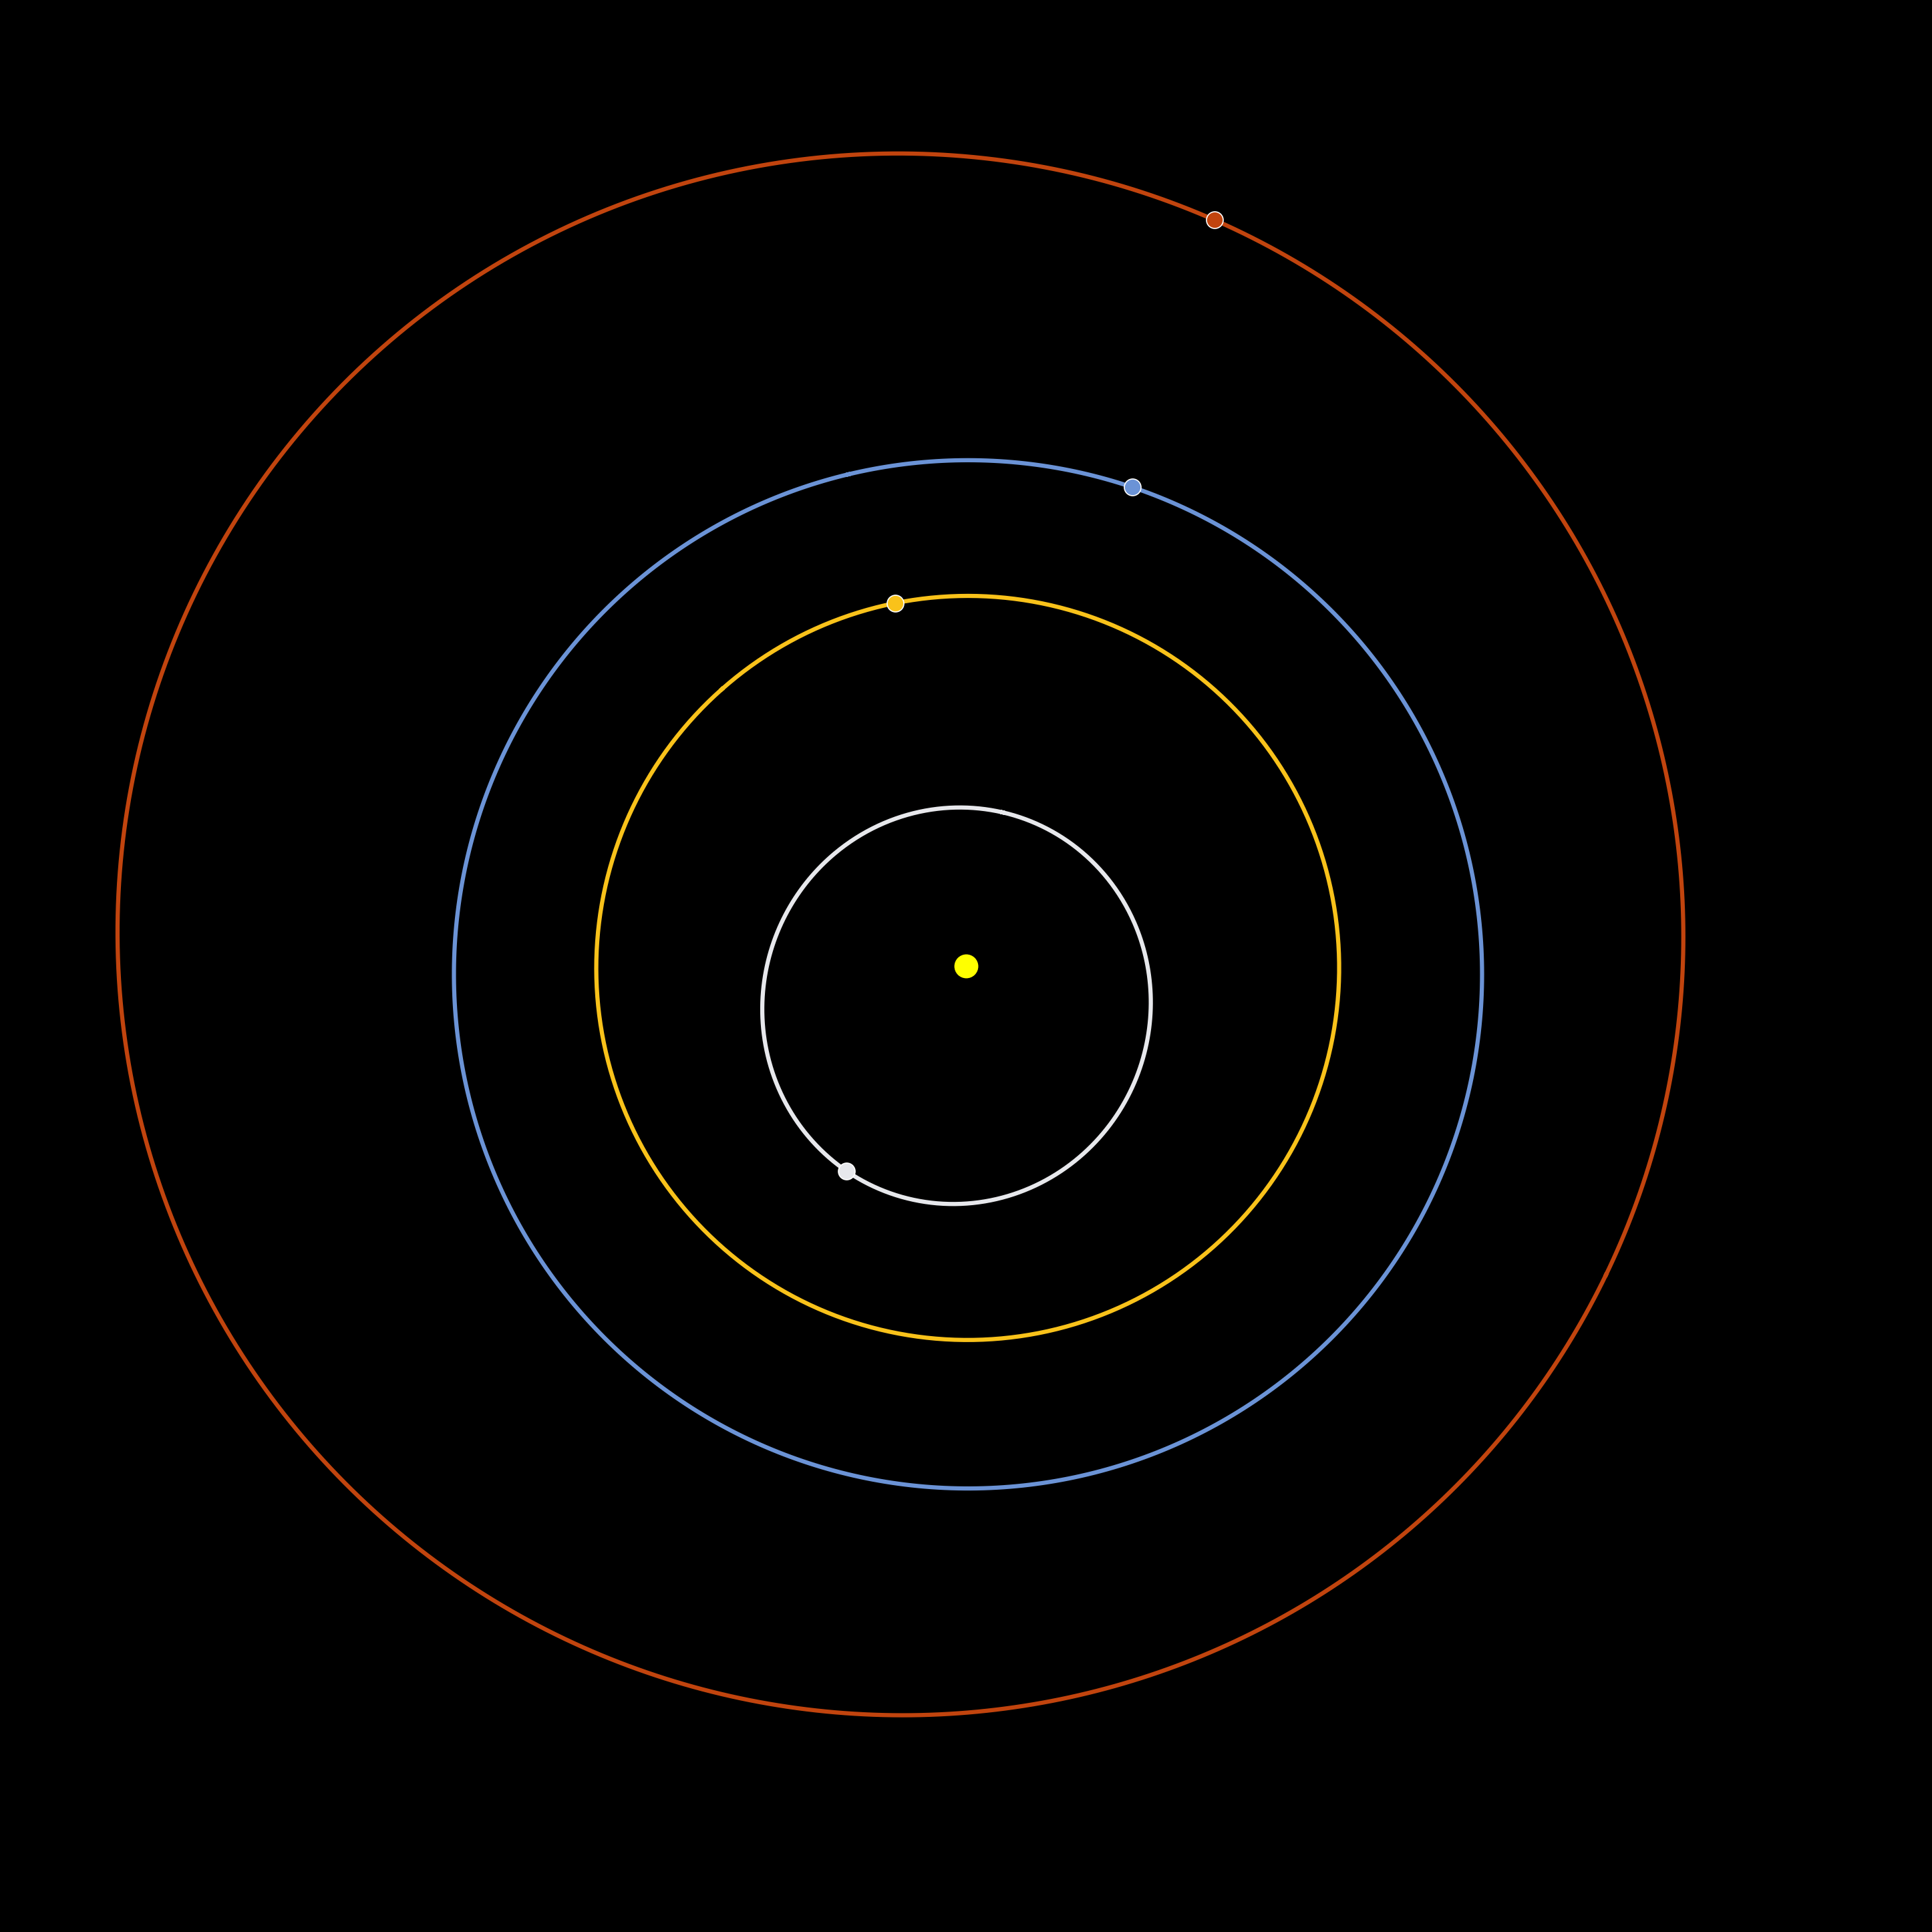

In [120]:
plotFile = f"MarsOppo_{dateTag}.png"
aMax = 1.8

# plot has dark background, 1:1 aspect

plt.style.use('dark_background')

fig,ax = plt.subplots(figsize=(wInches,hInches),dpi=dpi)
    
ax.tick_params('both',length=6,width=lwidth,which='major',direction='in',top='on',right='on')
ax.tick_params('both',length=3,width=lwidth,which='minor',direction='in',top='on',right='on')

# Limits

ax.set_xlim(-aMax,aMax)
ax.set_xticks([])
ax.set_ylim(-aMax,aMax)
ax.set_yticks([])
ax.set_axis_off()

ax.set_aspect(True)

# Planet orbits

for planet in planets:
    ax.plot(xOrb[planet],yOrb[planet],'-',lw=0.75,color=colors[planet],zorder=9)
    ax.plot(xP[planet],yP[planet],'o',ms=3,mfc=colors[planet],mec="white",mew=0.2,alpha=1,zorder=10)
    
# and the sun

ax.plot(0,0,'o',ms=4,mfc='yellow',mec='yellow',mew=0.3,alpha=1,zorder=10)

# save hardcopy

plt.savefig(plotFile,bbox_inches='tight',facecolor='black')

plt.show()